In [1]:
import os

for dirname, dirs, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            print(os.path.join(dirname, filename))

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv


In [2]:
import pandas as pd


metadata = pd.read_csv('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

print(f"Shape: {metadata.shape}")
print(f"\nClass distribution (dx column):")
print(metadata['dx'].value_counts())
print(f"\nClass distribution (percentage):")
print(metadata['dx'].value_counts(normalize=True).round(3) * 100)

Shape: (10015, 7)

Class distribution (dx column):
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Class distribution (percentage):
dx
nv       66.9
mel      11.1
bkl      11.0
bcc       5.1
akiec     3.3
vasc      1.4
df        1.1
Name: proportion, dtype: float64


In [3]:
import os


for dirname, dirs, filenames in os.walk('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'):
    if filenames and filenames[0].endswith('.jpg'):
        print(f"{dirname}: {len(filenames)} images")

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1: 5000 images
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_1: 5000 images
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2: 5015 images
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_2: 5015 images


In [4]:
import os
import pandas as pd


image_dirs = [
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1',
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2'
]


image_paths = {}
for folder in image_dirs:
    for filename in os.listdir(folder):
        image_id = os.path.splitext(filename)[0]  # strip .jpg
        image_paths[image_id] = os.path.join(folder, filename)

print(f"Total images mapped: {len(image_paths)}")
print(f"\nExample entry:")
example_id = list(image_paths.keys())[0]
print(f"  {example_id} -> {image_paths[example_id]}")

Total images mapped: 10015

Example entry:
  ISIC_0028933 -> /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg


In [5]:

metadata['filepath'] = metadata['image_id'].map(image_paths)


missing = metadata['filepath'].isna().sum()
print(f"Images with missing paths: {missing}")

print(f"\nSample rows:")
print(metadata[['image_id', 'dx', 'filepath']].head())

Images with missing paths: 0

Sample rows:
       image_id   dx                                           filepath
0  ISIC_0027419  bkl  /kaggle/input/datasets/kmader/skin-cancer-mnis...
1  ISIC_0025030  bkl  /kaggle/input/datasets/kmader/skin-cancer-mnis...
2  ISIC_0026769  bkl  /kaggle/input/datasets/kmader/skin-cancer-mnis...
3  ISIC_0025661  bkl  /kaggle/input/datasets/kmader/skin-cancer-mnis...
4  ISIC_0031633  bkl  /kaggle/input/datasets/kmader/skin-cancer-mnis...


Label encoding:
  0 -> akiec (327 images)
  1 -> bcc (514 images)
  2 -> bkl (1099 images)
  3 -> df (115 images)
  4 -> mel (1113 images)
  5 -> nv (6705 images)
  6 -> vasc (142 images)

Train size: 8012
Test size:  2003

Train class distribution:
dx
nv       5364
mel       890
bkl       879
bcc       411
akiec     262
vasc      114
df         92
Name: count, dtype: int64


In [7]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights inversely proportional to frequency
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(7),
    y=train_df['label'].values
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} ({i}): {class_weights[i]:.3f}")

Class weights:
  akiec (0): 4.369
  bcc (1): 2.785
  bkl (2): 1.302
  df (3): 12.441
  mel (4): 1.286
  nv (5): 0.213
  vasc (6): 10.040


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Custom Dataset class
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, 'filepath']).convert('RGB')
        label = self.df.loc[idx, 'label']
        if self.transform:
            img = self.transform(img)
        return img, label

# Transforms: augmentation for training, just resize/normalise for test
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Creating datasets and dataloaders
train_dataset = SkinLesionDataset(train_df, transform=train_transform)
test_dataset  = SkinLesionDataset(test_df,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 251
Test batches:  63


In [10]:
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet50(weights='IMAGENET1K_V1')


model.fc = nn.Linear(model.fc.in_features, 7)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Using device: {device}")
print(f"Output layer: {model.fc}")


Using device: cuda
Output layer: Linear(in_features=2048, out_features=7, bias=True)


In [12]:
import torch.optim as optim

# Weighted loss function to handle class imbalance
weights = torch.FloatTensor(list(class_weight_dict.values())).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# Optimiser: fine-tune whole network but with small learning rate
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Learning rate scheduler: reduce LR if validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

print("Loss function: CrossEntropyLoss with class weights")
print("Optimiser: Adam (lr=1e-4)")
print("Scheduler: ReduceLROnPlateau (patience=2)")

Loss function: CrossEntropyLoss with class weights
Optimiser: Adam (lr=1e-4)
Scheduler: ReduceLROnPlateau (patience=2)


In [13]:
from sklearn.metrics import balanced_accuracy_score

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_balanced_acc': []}

for epoch in range(10):
    # --- Training phase ---
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # --- Validation phase ---
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(test_loader)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_balanced_acc'].append(bal_acc)

    print(f"Epoch {epoch+1:02d}/10 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Balanced Acc: {bal_acc:.4f}")

print("\nTraining complete!")

Epoch 01/10 | Train Loss: 1.1400 | Val Loss: 1.0173 | Balanced Acc: 0.6535
Epoch 02/10 | Train Loss: 0.8848 | Val Loss: 0.8312 | Balanced Acc: 0.7090
Epoch 03/10 | Train Loss: 0.7765 | Val Loss: 0.7269 | Balanced Acc: 0.7462
Epoch 04/10 | Train Loss: 0.7374 | Val Loss: 0.7630 | Balanced Acc: 0.7190
Epoch 05/10 | Train Loss: 0.5949 | Val Loss: 0.5866 | Balanced Acc: 0.7816
Epoch 06/10 | Train Loss: 0.5957 | Val Loss: 0.7535 | Balanced Acc: 0.7452
Epoch 07/10 | Train Loss: 0.5954 | Val Loss: 0.6606 | Balanced Acc: 0.7599
Epoch 08/10 | Train Loss: 0.5376 | Val Loss: 0.6217 | Balanced Acc: 0.7879
Epoch 09/10 | Train Loss: 0.3925 | Val Loss: 0.5133 | Balanced Acc: 0.8372
Epoch 10/10 | Train Loss: 0.3659 | Val Loss: 0.5199 | Balanced Acc: 0.8376

Training complete!


In [14]:
from sklearn.metrics import classification_report

# Get final predictions
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=le.classes_))

              precision    recall  f1-score   support

       akiec       0.51      0.91      0.66        65
         bcc       0.66      0.85      0.75       103
         bkl       0.71      0.69      0.70       220
          df       0.56      0.96      0.71        23
         mel       0.47      0.72      0.57       223
          nv       0.96      0.81      0.88      1341
        vasc       0.76      0.93      0.84        28

    accuracy                           0.80      2003
   macro avg       0.66      0.84      0.73      2003
weighted avg       0.84      0.80      0.81      2003



In [15]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 83.5 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 104.0 MB/s eta 0:00:0000:010:01
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=772ba88fc097696cb6e938c4338eb1f102a1fea97353b58ced26b9e0906beb17
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3

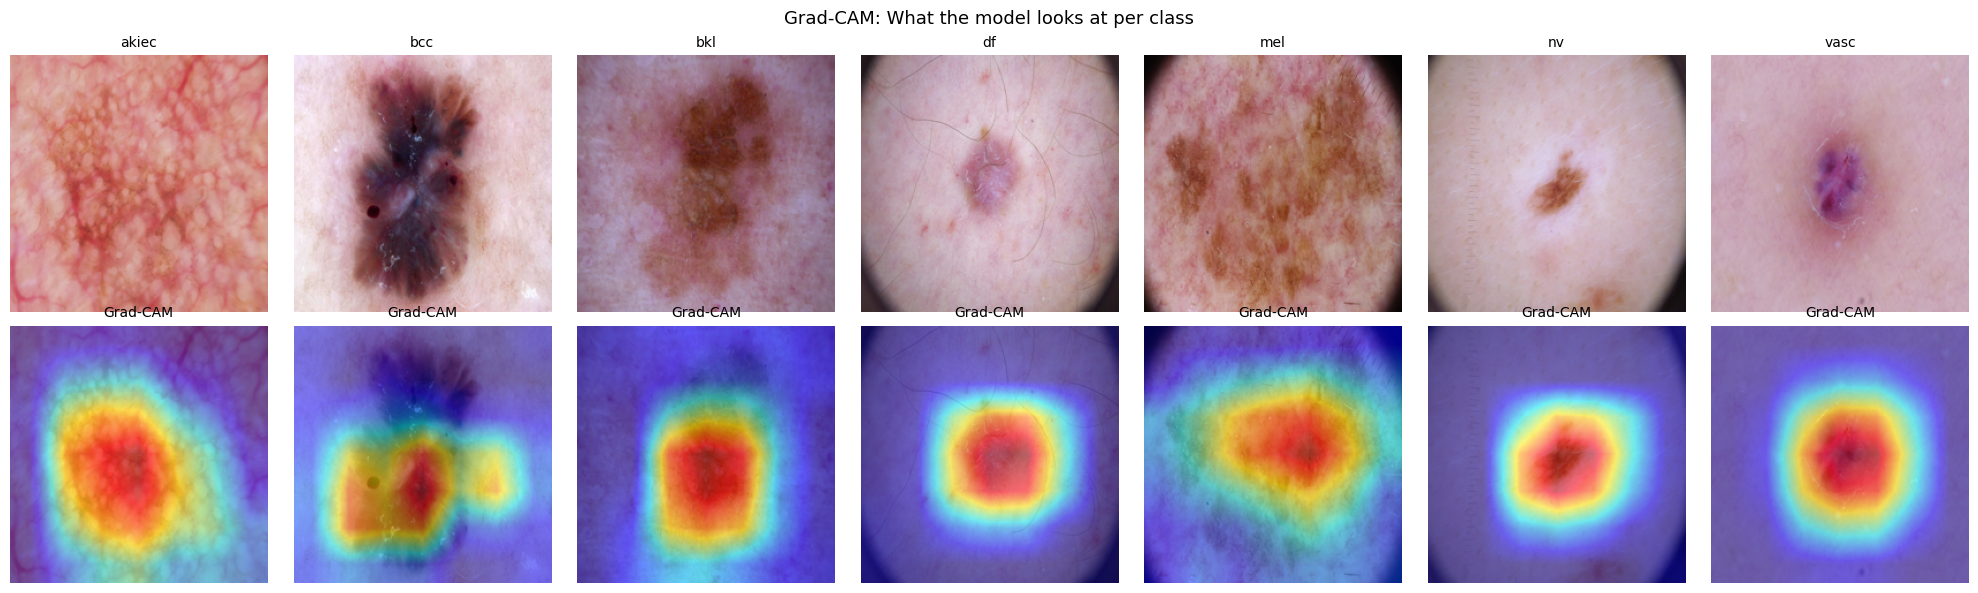

Saved!


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Target the last convolutional layer in ResNet50
target_layer = [model.layer4[-1]]

# Pick one example from each class to visualise
samples = []
for label_idx in range(7):
    row = test_df[test_df['label'] == label_idx].iloc[0]
    samples.append(row)

fig, axes = plt.subplots(2, 7, figsize=(20, 6))

with GradCAM(model=model, target_layers=target_layer) as cam:
    for i, row in enumerate(samples):
        # Load and preprocess image
        img = Image.open(row['filepath']).convert('RGB')
        img_resized = img.resize((224, 224))
        img_np = np.array(img_resized) / 255.0

        input_tensor = test_transform(img).unsqueeze(0).to(device)
        targets = [ClassifierOutputTarget(row['label'])]

        # Generate Grad-CAM
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        visualization = show_cam_on_image(img_np.astype(np.float32), grayscale_cam, use_rgb=True)

        # Plot original and heatmap
        axes[0, i].imshow(img_resized)
        axes[0, i].set_title(le.classes_[row['label']], fontsize=10)
        axes[0, i].axis('off')

        axes[1, i].imshow(visualization)
        axes[1, i].set_title('Grad-CAM', fontsize=10)
        axes[1, i].axis('off')

plt.suptitle('Grad-CAM: What the model looks at per class', fontsize=13)
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

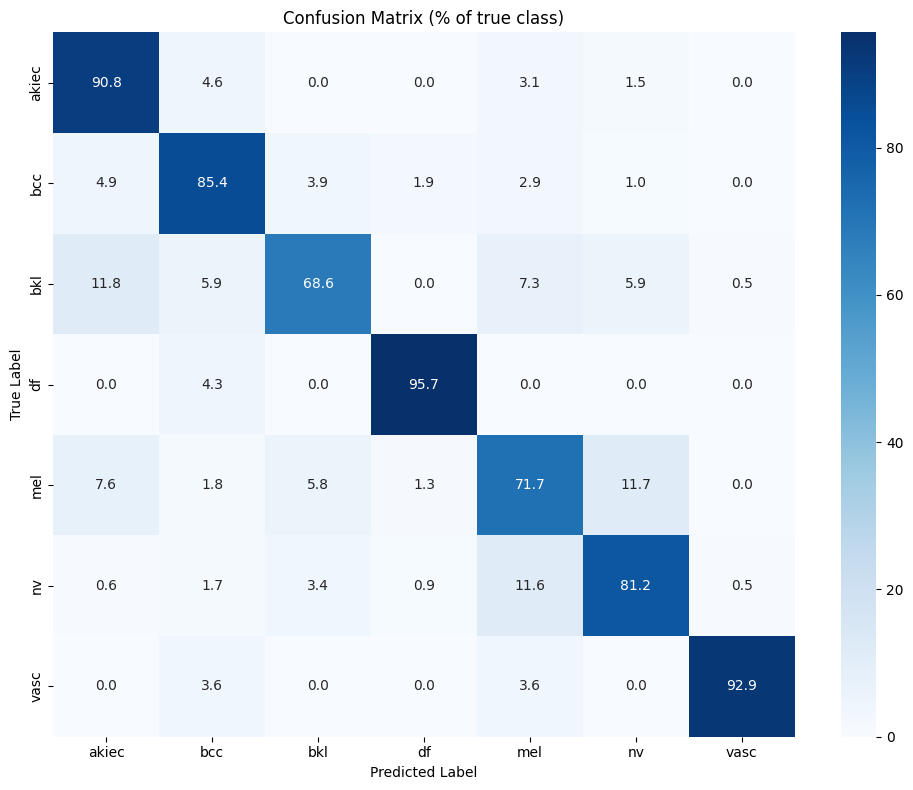

Saved!


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix (% of true class)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [18]:
import torch

# Save model weights
torch.save(model.state_dict(), 'skin_cancer_resnet50.pth')
print("Model saved as skin_cancer_resnet50.pth")

# Also save the label encoder classes so we can reload them later
import numpy as np
np.save('label_classes.npy', le.classes_)
print("Label classes saved as label_classes.npy")

Model saved as skin_cancer_resnet50.pth
Label classes saved as label_classes.npy


In [19]:
from torchvision import models
import torch.nn as nn

# Reload model from scratch
reload_model = models.resnet50(weights=None)
reload_model.fc = nn.Linear(reload_model.fc.in_features, 7)
reload_model.load_state_dict(torch.load('skin_cancer_resnet50.pth', map_location=device))
reload_model = reload_model.to(device)
reload_model.eval()

# Reload label classes
reload_classes = np.load('label_classes.npy', allow_pickle=True)

print("Model reloaded successfully!")
print(f"Classes: {reload_classes}")

Model reloaded successfully!
Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


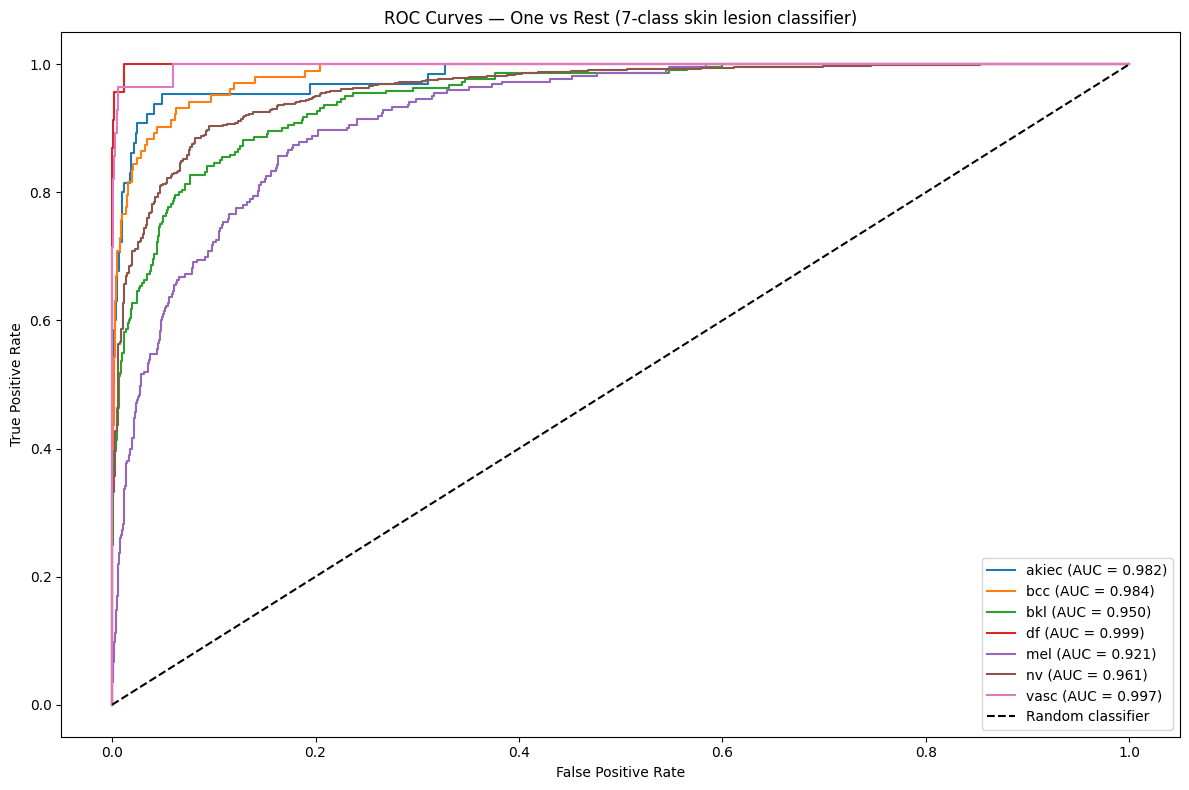

Saved!


In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Get predicted probabilities for all classes
model.eval()
all_probs, all_labels_roc = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels_roc.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels_roc = np.array(all_labels_roc)

# Binarize labels for one-vs-rest ROC
labels_bin = label_binarize(all_labels_roc, classes=np.arange(7))

# Plot ROC curve for each class
plt.figure(figsize=(12, 8))

for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — One vs Rest (7-class skin lesion classifier)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [21]:
# Find misclassified melanoma cases (most clinically important)
model.eval()
wrong_mel = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        
        for i in range(len(labels)):
            true = labels[i].item()
            pred = preds[i].item()
            if true == 4 and pred != 4:  # mel misclassified
                wrong_mel.append({
                    'true': true,
                    'pred': pred,
                    'image': images[i].cpu()
                })
        
        if len(wrong_mel) >= 6:
            break

print(f"Found {len(wrong_mel)} misclassified melanoma cases to visualise")

Found 6 misclassified melanoma cases to visualise


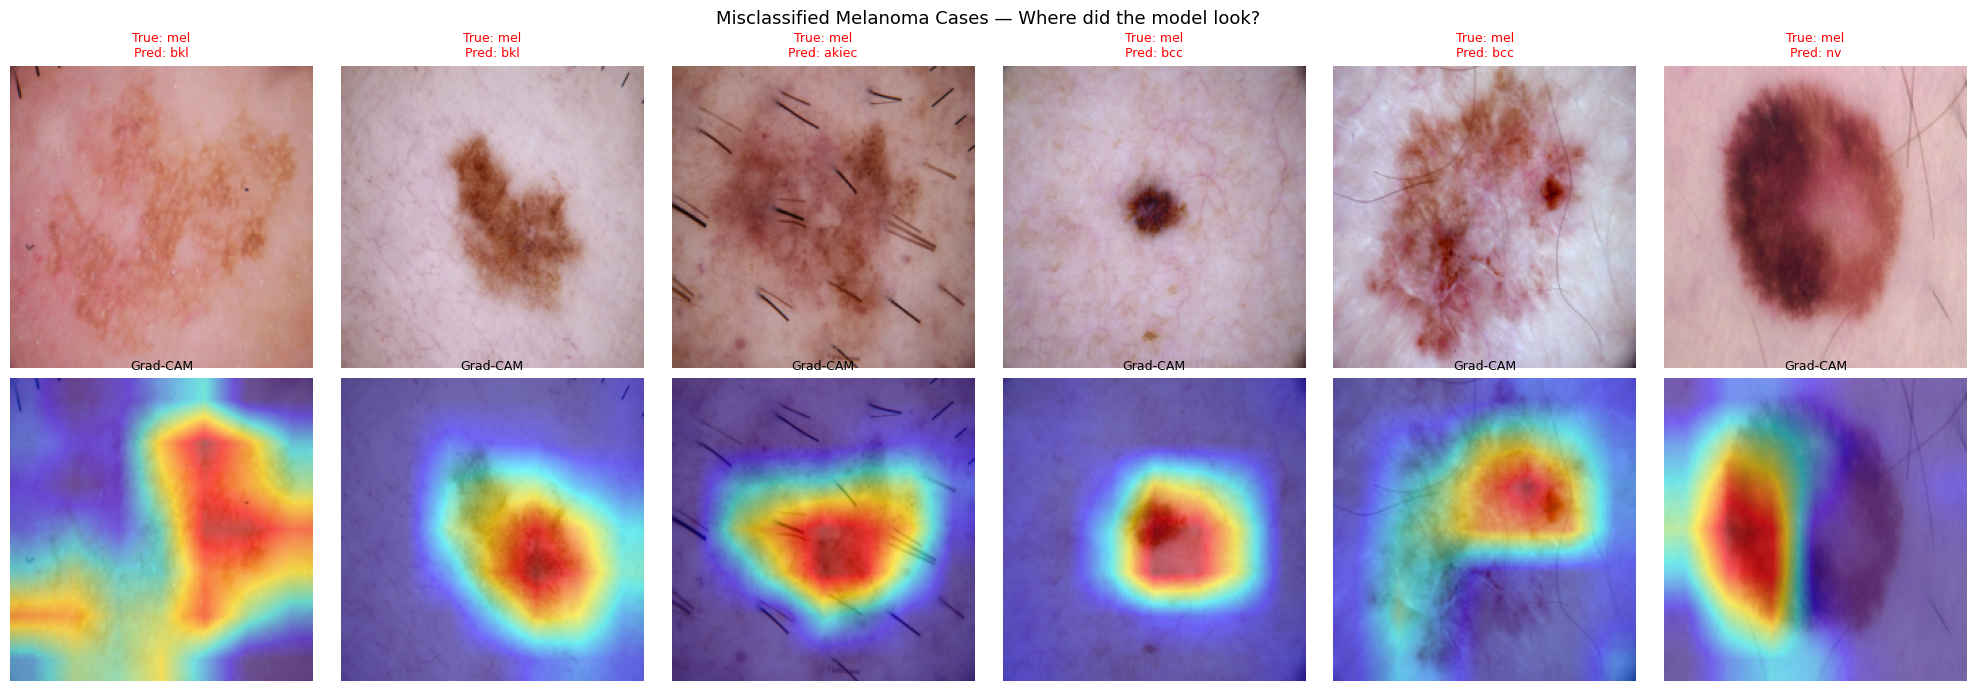

Saved!


In [22]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

with GradCAM(model=model, target_layers=target_layer) as cam:
    for i, sample in enumerate(wrong_mel):
        img_tensor = sample['image']
        true_label = le.classes_[sample['true']]
        pred_label = le.classes_[sample['pred']]

        # Denormalise for display
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = (img_np * std + mean).clip(0, 1)

        # Grad-CAM
        input_tensor = img_tensor.unsqueeze(0).to(device)
        targets = [ClassifierOutputTarget(sample['true'])]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        visualization = show_cam_on_image(img_np.astype(np.float32), grayscale_cam, use_rgb=True)

        # Plot
        axes[0, i].imshow(img_np)
        axes[0, i].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=9, color='red')
        axes[0, i].axis('off')

        axes[1, i].imshow(visualization)
        axes[1, i].set_title('Grad-CAM', fontsize=9)
        axes[1, i].axis('off')

plt.suptitle('Misclassified Melanoma Cases — Where did the model look?', fontsize=13)
plt.tight_layout()
plt.savefig('gradcam_wrong_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")